# Dueling DQN 

## Objetivo de la iteración

En esta iteración se combina **Double DQN** con una arquitectura **Dueling DQN**. El cálculo Double DQN mantiene separadas la selección y la evaluación de la siguiente acción, mientras que la arquitectura Dueling modifica la forma en que la red estima los valores Q.

Una red DQN tradicional produce directamente un valor $Q(s,a)$ para cada acción. En cambio, Dueling DQN divide la salida de la red en dos componentes:

- **Valor del estado, $V(s)$:** estima qué tan favorable es el estado actual, independientemente de la acción seleccionada.
- **Ventaja de la acción, $A(s,a)$:** estima cuánto mejor o peor es ejecutar una acción respecto a las demás acciones disponibles en ese estado.

Ambos componentes se combinan mediante:

$$
Q(s,a) =
V(s)
+
\left(
A(s,a)
-
\frac{1}{|\mathcal{A}|}
\sum_{a'} A(s,a')
\right)
$$

Se resta la ventaja promedio para evitar que $V(s)$ y $A(s,a)$ puedan representar de múltiples formas los mismos valores Q.

Esta separación puede ser útil en estados donde varias acciones tienen efectos similares. Por ejemplo, en ciertos momentos de Space Invaders, el valor general de la situación puede ser más importante que distinguir inmediatamente entre todas las acciones disponibles.

En este experimento se utilizará **Dueling Double DQN**:

1. La arquitectura Dueling separará el valor del estado y las ventajas de las acciones.
2. La red online seleccionará la siguiente acción.
3. La red target evaluará la acción seleccionada.

Se mantendrán los mismos hiperparámetros y condiciones de evaluación utilizados en DQN vanilla y Double DQN, para que la comparación se concentre en el efecto de la arquitectura.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from models import DQN, DuelingDQN
from replay_buffer import ReplayBuffer
from train import ConfigDQN, actualizar_modelo, entrenar_dqn
from evaluation import evaluar_modelo

SEMILLA = 42
N_ACCIONES = 6

np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Dispositivo seleccionado: {device}")
print(f"Número de acciones: {N_ACCIONES}")
print(f"Semilla: {SEMILLA}")

Dispositivo seleccionado: mps
Número de acciones: 6
Semilla: 42


In [16]:
modelo_dueling_prueba = DuelingDQN(
    n_acciones=N_ACCIONES
).to(device)

observaciones_prueba = torch.randint(
    low=0,
    high=256,
    size=(2, 4, 84, 84),
    dtype=torch.uint8,
    device=device,
)

with torch.no_grad():
    valores_q_prueba = modelo_dueling_prueba(
        observaciones_prueba
    )

parametros_dueling = sum(
    parametro.numel()
    for parametro in modelo_dueling_prueba.parameters()
)

modelo_dqn_prueba = DQN(
    n_acciones=N_ACCIONES
).to(device)

parametros_dqn = sum(
    parametro.numel()
    for parametro in modelo_dqn_prueba.parameters()
)

print("VERIFICACIÓN DE LA ARQUITECTURA")
print(
    f"Forma de entrada: "
    f"{observaciones_prueba.shape}"
)
print(
    f"Forma de salida: "
    f"{valores_q_prueba.shape}"
)
print(
    f"Parámetros DQN tradicional: "
    f"{parametros_dqn:,}"
)
print(
    f"Parámetros Dueling DQN: "
    f"{parametros_dueling:,}"
)
print(
    f"Diferencia de parámetros: "
    f"{parametros_dueling - parametros_dqn:,}"
)

print("\nValores Q de prueba:")
print(valores_q_prueba)

assert valores_q_prueba.shape == (2, N_ACCIONES)
assert torch.isfinite(valores_q_prueba).all()

print("\nLa arquitectura Dueling produce la salida correcta.")

VERIFICACIÓN DE LA ARQUITECTURA
Forma de entrada: torch.Size([2, 4, 84, 84])
Forma de salida: torch.Size([2, 6])
Parámetros DQN tradicional: 1,687,206
Parámetros Dueling DQN: 3,293,863
Diferencia de parámetros: 1,606,657

Valores Q de prueba:
tensor([[ 0.0144, -0.0443,  0.0179, -0.0718, -0.0552, -0.0582],
        [ 0.0266, -0.0426,  0.0210, -0.0588, -0.0498, -0.0453]],
       device='mps:0')

La arquitectura Dueling produce la salida correcta.


In [17]:
del modelo_dueling_prueba
del modelo_dqn_prueba
del observaciones_prueba

In [ ]:
config_dueling = ConfigDQN(
    nombre_experimento="v3_dueling_double_dqn",
    total_pasos=500_000,

    gamma=0.99,
    learning_rate=1e-4,
    batch_size=32,
    frecuencia_entrenamiento=4,

    capacidad_buffer=20_000,
    inicio_entrenamiento=10_000,
    frecuencia_actualizacion_target=10_000,
    gradient_clip=10.0,

    epsilon_inicial=1.0,
    epsilon_final=0.1,
    pasos_decay_epsilon=250_000,

    frecuencia_evaluacion=50_000,
    episodios_evaluacion=5,
    seed_evaluacion=1_000,
    frecuencia_log=1_000,

    terminal_on_life_loss=True,
    clip_reward=True,
)

resultado_dueling = entrenar_dqn(
    config=config_dueling,
    clase_modelo=DuelingDQN,
    device=device,
    usar_double_dqn=True,  
)

A.L.E: Arcade Learning Environment (version 0.10.1+6a7e0ae)
[Powered by Stella]


Paso 10,000/500,000 | episodio=50 | epsilon=0.964 | loss=0.0009 | Q=0.031
Paso 11,000/500,000 | episodio=54 | epsilon=0.960 | loss=0.0007 | Q=0.090
Paso 12,000/500,000 | episodio=57 | epsilon=0.957 | loss=0.0162 | Q=0.070
Paso 13,000/500,000 | episodio=63 | epsilon=0.953 | loss=0.0015 | Q=0.071
Paso 14,000/500,000 | episodio=69 | epsilon=0.950 | loss=0.0001 | Q=0.061
Paso 15,000/500,000 | episodio=74 | epsilon=0.946 | loss=0.0286 | Q=0.098
Paso 16,000/500,000 | episodio=81 | epsilon=0.942 | loss=0.0140 | Q=0.089
Paso 17,000/500,000 | episodio=86 | epsilon=0.939 | loss=0.0010 | Q=0.069
Paso 18,000/500,000 | episodio=93 | epsilon=0.935 | loss=0.0316 | Q=0.043
Paso 19,000/500,000 | episodio=98 | epsilon=0.932 | loss=0.0005 | Q=0.088
Paso 20,000/500,000 | episodio=104 | epsilon=0.928 | loss=0.0008 | Q=0.080
Paso 21,000/500,000 | episodio=110 | epsilon=0.924 | loss=0.0152 | Q=0.101
Paso 22,000/500,000 | episodio=115 | epsilon=0.921 | loss=0.0005 | Q=0.098
Paso 23,000/500,000 | episodio=121 

## Evaluaciones

In [9]:
from pathlib import Path

ruta_evaluaciones_dueling = Path(
    "../logs/entrenamientos/v3_dueling_double_dqn/evaluaciones.csv"
)

df_evaluaciones_dueling = pd.read_csv(
    ruta_evaluaciones_dueling
)

df_evaluaciones_dueling = (
    df_evaluaciones_dueling
    .sort_values("paso_global")
    .reset_index(drop=True)
)

display(df_evaluaciones_dueling)

mejor_evaluacion_dueling = df_evaluaciones_dueling.loc[
    df_evaluaciones_dueling["promedio"].idxmax()
]

print("\nMEJOR EVALUACIÓN DE DUELING DOUBLE DQN")
print(
    f"Paso: "
    f"{int(mejor_evaluacion_dueling['paso_global']):,}"
)
print(
    f"Promedio: "
    f"{mejor_evaluacion_dueling['promedio']:.2f}"
)
print(
    f"Mediana: "
    f"{mejor_evaluacion_dueling['mediana']:.2f}"
)
print(
    f"Desviación: "
    f"{mejor_evaluacion_dueling['desviacion']:.2f}"
)
print(
    f"Mínimo: "
    f"{mejor_evaluacion_dueling['minimo']:.2f}"
)
print(
    f"Máximo: "
    f"{mejor_evaluacion_dueling['maximo']:.2f}"
)

ruta_mejor_dueling = Path(
    "../models/v3_dueling_double_dqn/mejor_modelo.pt"
)

print(
    "\nCheckpoint del mejor modelo: "
    f"{'OK' if ruta_mejor_dueling.exists() else 'NO ENCONTRADO'}"
)

,paso_global,promedio,mediana,desviacion,minimo,maximo
0,50000,110.0,135.0,37.549967,45.0,140.0
1,100000,159.0,160.0,78.255990,30.0,270.0
2,150000,164.0,155.0,41.279535,110.0,225.0
3,200000,159.0,165.0,44.654227,85.0,215.0
4,250000,229.0,155.0,132.151428,125.0,485.0
5,300000,384.0,350.0,116.764721,245.0,595.0
6,350000,386.0,380.0,164.511398,155.0,665.0
7,400000,242.0,215.0,88.915690,145.0,410.0
8,450000,406.0,400.0,103.508454,240.0,565.0
9,500000,295.0,295.0,74.363970,205.0,390.0



MEJOR EVALUACIÓN DE DUELING DOUBLE DQN
Paso: 450,000
Promedio: 406.00
Mediana: 400.00
Desviación: 103.51
Mínimo: 240.00
Máximo: 565.00

Checkpoint del mejor modelo: OK


In [13]:
N_EPISODIOS_EVALUACION = 30
SEMILLA_BASE_EVALUACION = 42  

checkpoint_dueling = torch.load(
    ruta_mejor_dueling,
    map_location=device,
    weights_only=True,
)

mejor_dueling_dqn = DuelingDQN(
    n_acciones=N_ACCIONES
).to(device)

mejor_dueling_dqn.load_state_dict(
    checkpoint_dueling["modelo_online_state_dict"]
)

mejor_dueling_dqn.eval()

print(
    f"Checkpoint cargado desde el paso: "
    f"{checkpoint_dueling['paso']:,}"
)

print(
    f"\nEvaluando Dueling Double DQN durante "
    f"{N_EPISODIOS_EVALUACION} episodios...\n"
)

resultados_dueling, resumen_dueling = evaluar_modelo(
    modelo=mejor_dueling_dqn,
    config=config_dueling,
    device=device,
    n_episodios=N_EPISODIOS_EVALUACION,
    seed_base=SEMILLA_BASE_EVALUACION,
)

df_dueling_dqn = pd.DataFrame(resultados_dueling)
df_dueling_dqn["agente"] = "Dueling Double DQN"

df_dueling_dqn = df_dueling_dqn[
    [
        "agente",
        "episodio",
        "seed",
        "recompensa_total",
        "pasos",
        "terminated",
        "truncated",
    ]
]

print("RESUMEN DE 30 EPISODIOS")

for metrica, valor in resumen_dueling.items():
    print(f"{metrica}: {valor:.2f}")

display(df_dueling_dqn.head(10))

Checkpoint cargado desde el paso: 450,000

Evaluando Dueling Double DQN durante 30 episodios...

RESUMEN DE 30 EPISODIOS
promedio: 263.33
mediana: 215.00
desviacion: 110.95
minimo: 155.00
maximo: 580.00


,agente,episodio,seed,recompensa_total,pasos,terminated,truncated
0,Dueling Double DQN,0,42,505.0,657,True,False
1,Dueling Double DQN,1,43,290.0,581,True,False
2,Dueling Double DQN,2,44,330.0,719,True,False
3,Dueling Double DQN,3,45,215.0,509,True,False
4,Dueling Double DQN,4,46,365.0,765,True,False
5,Dueling Double DQN,5,47,320.0,781,True,False
6,Dueling Double DQN,6,48,215.0,689,True,False
7,Dueling Double DQN,7,49,215.0,539,True,False
8,Dueling Double DQN,8,50,210.0,399,True,False
9,Dueling Double DQN,9,51,580.0,734,True,False


In [14]:
ruta_resultados_dueling = Path(
    "../logs/evaluacion_dueling_double_dqn.csv"
)

df_dueling_dqn.to_csv(
    ruta_resultados_dueling,
    index=False,
)

df_baseline = pd.read_csv(
    "../logs/baseline_episodios.csv"
)

df_dqn_vanilla = pd.read_csv(
    "../logs/evaluacion_dqn_vanilla.csv"
)

df_double_dqn = pd.read_csv(
    "../logs/evaluacion_double_dqn.csv"
)

columnas_comparacion = [
    "agente",
    "episodio",
    "seed",
    "recompensa_total",
    "pasos",
    "terminated",
    "truncated",
]

df_comparacion_modelos = pd.concat(
    [
        df_baseline[columnas_comparacion],
        df_dqn_vanilla[columnas_comparacion],
        df_double_dqn[columnas_comparacion],
        df_dueling_dqn[columnas_comparacion],
    ],
    ignore_index=True,
)

resumen_comparacion_modelos = (
    df_comparacion_modelos
    .groupby("agente")
    .agg(
        episodios=("recompensa_total", "count"),
        promedio=("recompensa_total", "mean"),
        mediana=("recompensa_total", "median"),
        desviacion=("recompensa_total", "std"),
        minimo=("recompensa_total", "min"),
        maximo=("recompensa_total", "max"),
        pasos_promedio=("pasos", "mean"),
    )
    .round(2)
    .reset_index()
)

display(resumen_comparacion_modelos)

#comparación pareada entre los tres agentes de RL usando las mismas semillas
comparacion_rl = (
    pd.concat(
        [
            df_dqn_vanilla,
            df_double_dqn,
            df_dueling_dqn,
        ],
        ignore_index=True,
    )
    .pivot(
        index="seed",
        columns="agente",
        values="recompensa_total",
    )
    .reset_index()
)

pares_a_comparar = [
    ("DQN vanilla", "Double DQN"),
    ("DQN vanilla", "Dueling Double DQN"),
    ("Double DQN", "Dueling Double DQN"),
]

for agente_a, agente_b in pares_a_comparar:
    diferencia = comparacion_rl[agente_b] - comparacion_rl[agente_a]

    print(f"\n{agente_a}  vs.  {agente_b}")
    print(f"Victorias {agente_a}: {(diferencia < 0).sum()}")
    print(f"Victorias {agente_b}: {(diferencia > 0).sum()}")
    print(f"Empates: {(diferencia == 0).sum()}")

print(f"\nResultados guardados en: {ruta_resultados_dueling}")

,agente,episodios,promedio,mediana,desviacion,minimo,maximo,pasos_promedio
0,Aleatorio,30,165.67,137.5,99.26,35.0,485.0,524.03
1,DQN vanilla,30,406.67,377.5,139.11,215.0,670.0,705.80
2,Double DQN,30,283.33,262.5,154.85,105.0,925.0,614.73
3,Dueling Double DQN,30,263.33,215.0,112.84,155.0,580.0,597.50
4,Regla simple,30,211.50,190.0,95.49,55.0,360.0,569.33



DQN vanilla  vs.  Double DQN
Victorias DQN vanilla: 23
Victorias Double DQN: 7
Empates: 0

DQN vanilla  vs.  Dueling Double DQN
Victorias DQN vanilla: 26
Victorias Dueling Double DQN: 4
Empates: 0

Double DQN  vs.  Dueling Double DQN
Victorias Double DQN: 15
Victorias Dueling Double DQN: 14
Empates: 1

Resultados guardados en: ../logs/evaluacion_dueling_double_dqn.csv


In [15]:
df_modelos_entrenados = pd.concat(
    [
        df_dqn_vanilla,
        df_double_dqn,
        df_dueling_dqn
    ],
    ignore_index=True,
)

df_modelos_entrenados["bloque_de_5"] = (
    df_modelos_entrenados["episodio"] // 5
) + 1

mejores_de_5_modelos = (
    df_modelos_entrenados
    .groupby(
        ["agente", "bloque_de_5"],
        as_index=False,
    )
    .agg(
        mejor_recompensa=("recompensa_total", "max"),
        promedio_bloque=("recompensa_total", "mean"),
    )
)

mejores_de_5_modelos["promedio_bloque"] = (
    mejores_de_5_modelos["promedio_bloque"].round(2)
)

display(mejores_de_5_modelos)

resumen_competencia = (
    mejores_de_5_modelos
    .groupby("agente")
    .agg(
        mejor_de_5_promedio=("mejor_recompensa", "mean"),
        mejor_de_5_mediana=("mejor_recompensa", "median"),
        menor_mejor_de_5=("mejor_recompensa", "min"),
        mayor_mejor_de_5=("mejor_recompensa", "max"),
    )
    .round(2)
    .reset_index()
)

print("\nRESUMEN DEL CRITERIO DE COMPETENCIA")
display(resumen_competencia)

,agente,bloque_de_5,mejor_recompensa,promedio_bloque
0,DQN vanilla,1,540.0,350.0
1,DQN vanilla,2,420.0,321.0
2,DQN vanilla,3,670.0,451.0
3,DQN vanilla,4,660.0,468.0
4,DQN vanilla,5,645.0,398.0
5,DQN vanilla,6,585.0,452.0
6,Double DQN,1,340.0,262.0
7,Double DQN,2,310.0,231.0
8,Double DQN,3,405.0,268.0
9,Double DQN,4,370.0,236.0



RESUMEN DEL CRITERIO DE COMPETENCIA


,agente,mejor_de_5_promedio,mejor_de_5_mediana,menor_mejor_de_5,mayor_mejor_de_5
0,DQN vanilla,586.67,615.0,420.0,670.0
1,Double DQN,476.67,387.5,310.0,925.0
2,Dueling Double DQN,434.17,432.5,285.0,580.0


## Curvas comparativas

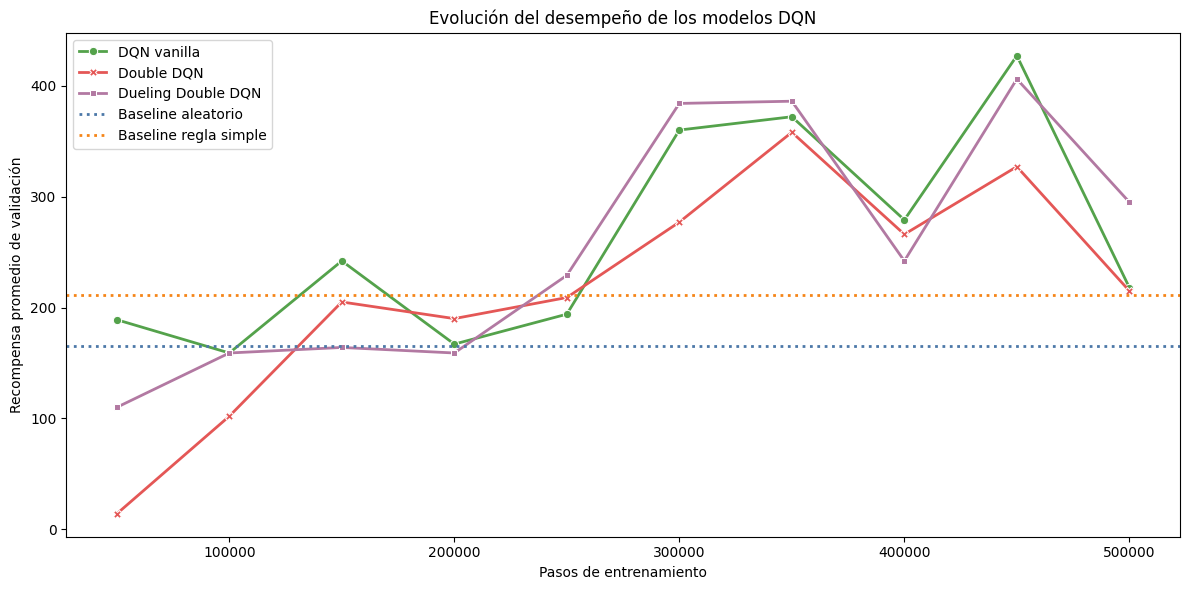

In [18]:
df_eval_vanilla = pd.read_csv(
    "../logs/entrenamientos/v1_dqn_vanilla/evaluaciones.csv"
)

df_eval_double = pd.read_csv(
    "../logs/entrenamientos/v2_double_dqn/evaluaciones.csv"
)

df_eval_dueling = pd.read_csv(
    "../logs/entrenamientos/v3_dueling_double_dqn/evaluaciones.csv"
)

df_eval_vanilla["modelo"] = "DQN vanilla"
df_eval_double["modelo"] = "Double DQN"
df_eval_dueling["modelo"] = "Dueling Double DQN"

df_curvas_entrenamiento = pd.concat(
    [
        df_eval_vanilla,
        df_eval_double,
        df_eval_dueling,
    ],
    ignore_index=True,
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_curvas_entrenamiento,
    x="paso_global",
    y="promedio",
    hue="modelo",
    style="modelo",
    markers=True,
    dashes=False,
    linewidth=2,
    palette={
        "DQN vanilla": "#54A24B",
        "Double DQN": "#E45756",
        "Dueling Double DQN": "#B279A2",
    },
)

plt.axhline(
    y=165.67,
    color="#4C78A8",
    linestyle=":",
    linewidth=2,
    label="Baseline aleatorio",
)

plt.axhline(
    y=211.50,
    color="#F58518",
    linestyle=":",
    linewidth=2,
    label="Baseline regla simple",
)

plt.title(
    "Evolución del desempeño de los modelos DQN"
)
plt.xlabel("Pasos de entrenamiento")
plt.ylabel("Recompensa promedio de validación")
plt.legend()
plt.tight_layout()
plt.show()

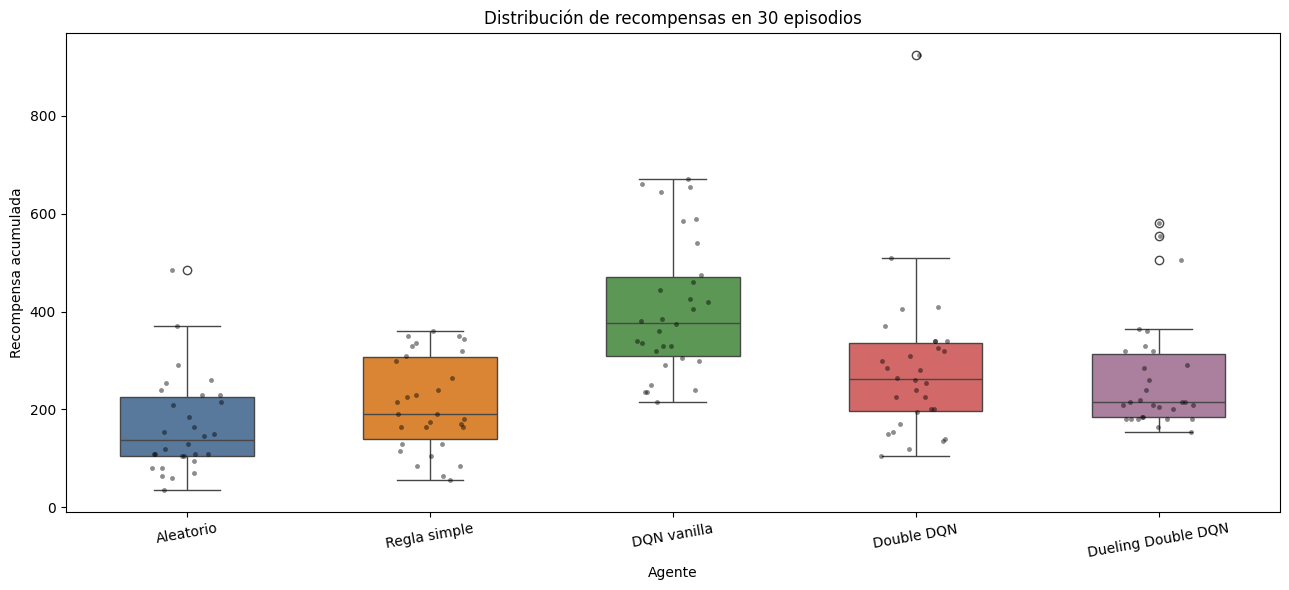

In [19]:
orden_agentes = [
    "Aleatorio",
    "Regla simple",
    "DQN vanilla",
    "Double DQN",
    "Dueling Double DQN",
]

colores_agentes = {
    "Aleatorio": "#4C78A8",
    "Regla simple": "#F58518",
    "DQN vanilla": "#54A24B",
    "Double DQN": "#E45756",
    "Dueling Double DQN": "#B279A2",
}

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df_comparacion_modelos,
    x="agente",
    y="recompensa_total",
    order=orden_agentes,
    hue="agente",
    palette=colores_agentes,
    legend=False,
    width=0.55,
)

sns.stripplot(
    data=df_comparacion_modelos,
    x="agente",
    y="recompensa_total",
    order=orden_agentes,
    color="black",
    alpha=0.45,
    jitter=0.15,
    size=3.5,
)

plt.title(
    "Distribución de recompensas en 30 episodios"
)
plt.xlabel("Agente")
plt.ylabel("Recompensa acumulada")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Conclusiones de la iteración V3: Dueling Double DQN

Dueling Double DQN fue entrenado durante **500,000 pasos**, combinando el cálculo de targets de Double DQN con una arquitectura que separa el valor del estado y la ventaja de cada acción.

La arquitectura Dueling contiene **3,293,863 parámetros**, frente a los **1,687,206 parámetros** del DQN tradicional. Esto representa un aumento de **1,606,657 parámetros**, debido principalmente a la utilización de flujos separados para estimar el valor y las ventajas.

El mejor checkpoint se obtuvo en el paso **450,000**, con los siguientes resultados de validación en cinco episodios:

| Métrica | Resultado |
|---|---:|
| Promedio | 406.00 |
| Mediana | 400.00 |
| Desviación estándar | 103.51 |
| Mínimo | 240 |
| Máximo | 565 |

Posteriormente, el mejor checkpoint fue evaluado durante 30 episodios con las mismas semillas utilizadas para los demás modelos:

| Métrica | Resultado |
|---|---:|
| Promedio | 263.33 |
| Mediana | 215.00 |
| Desviación estándar | 110.95 |
| Mínimo | 155 |
| Máximo | 580 |

Dueling Double DQN superó el promedio del agente aleatorio y el de la regla simple. Su recompensa promedio fue aproximadamente **58.95 % mayor** que la del agente aleatorio y **24.50 % mayor** que la obtenida por la regla simple. Por lo tanto, el modelo sí aprendió una política útil.

Sin embargo, no superó las otras variantes entrenadas. En la comparación pareada, DQN vanilla obtuvo una recompensa mayor en **26 de los 30 episodios**, mientras Dueling Double DQN ganó en solamente **4**. La comparación con Double DQN fue más equilibrada: Double DQN ganó 15 episodios, Dueling ganó 14 y se produjo un empate.

La arquitectura Dueling no produjo una mejora respecto a los modelos anteriores, a pesar de contar con una mayor cantidad de parámetros. Una posible explicación es que la mayor complejidad requiera otros hiperparámetros, una mayor cantidad de pasos o más de una semilla de entrenamiento para mostrar una ventaja consistente.